# Dose-response: does MedGemma follow the anatomy?

**Questions** (PLAN.md, checks after the first audit and the day-4 decision rule).
1. Cardiomegaly: as the heart is enlarged step by step (grown-heart mask at 6 strengths, from the
   heart's own outline to the audit's +30%), where does each model switch to "yes", measured in
   CTR, and is that near the clinical 0.5? Same question on all real PA test films.
2. Effusion: does blurring the lung bases (no RadEdit) raise P(yes)? If so, the sham drift can be
   lost normal detail meeting the "yes" prior rather than a RadEdit trace.
3. Are the scores deterministic (re-scored images against the audit)?

**Switch point.** A logistic curve of P(yes) against the measured CTR (segmenter), fitted with
P(yes) as a soft label (each film counts as "yes" with weight P(yes) and "no" with weight
1 - P(yes)). The switch point is the CTR where the curve crosses 0.5; 95% CI by resampling
patients. Step 2 of the day-4 rule applies if the CI for the edited films does not overlap
0.47-0.53.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

ROOT = Path.cwd().parent  # the notebook runs from notebooks/
sys.path.insert(0, str(ROOT))
from cxr.data import ACCENT, AXIS, GRID, INK, INK_2, MUTED, SURFACE

R = ROOT / "results"
models = ["4b", "1.5-4b"]
measures = pd.read_csv(R / "dose_measures.csv")
keys = ["group", "finding", "image", "level"]
scores = {m: pd.read_csv(R / f"dose_scores_{m}.csv").merge(
    measures.drop(columns="patient_id"), on=keys, how="left") for m in models}
audit = {m: pd.read_csv(R / f"audit_{m}_test.csv") for m in models}
thresholds = {m: pd.read_csv(R / f"audit_{m}_thresholds.csv") for m in models}
logit = lambda p: np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))
print(measures.groupby(["group", "finding"], dropna=False).size().to_string())

group     finding     
blur      effusion         200
dose      cardiomegaly     600
original  effusion         100
real      cardiomegaly    1883
sham      effusion         100


## 1. Determinism: re-scored images against the audit

In [2]:
rows = []
for m in models:
    s, a = scores[m], audit[m]
    for name, mine, theirs in [
        ("real originals (cardiomegaly)", s[(s["group"] == "real")], a[(a["finding"] == "cardiomegaly") & (a["variant"] == "original")]),
        ("+30% edits", s[(s["group"] == "dose") & (s["level"] == 0.30)], a[(a["finding"] == "cardiomegaly") & (a["variant"] == "edit")]),
        ("effusion originals", s[(s["group"] == "original")], a[(a["finding"] == "effusion") & (a["variant"] == "original")]),
        ("effusion shams", s[(s["group"] == "sham")], a[(a["finding"] == "effusion") & (a["variant"] == "sham")])]:
        j = mine.merge(theirs[["image", "phrasing", "p_yes"]], on=["image", "phrasing"], suffixes=("", "_audit"))
        d = np.abs(logit(j["p_yes"]) - logit(j["p_yes_audit"]))
        rows.append({"model": m, "images": name, "n": len(j), "max_abs_diff_p_yes": np.abs(j["p_yes"] - j["p_yes_audit"]).max(),
                     "max_abs_diff_log_odds": d.max(), "share_identical_5_decimals": (j["p_yes"] == j["p_yes_audit"]).mean()})
determinism = pd.DataFrame(rows).round(5)
determinism.to_csv(R / "dose_determinism.csv", index=False)
determinism

,model,images,n,max_abs_diff_p_yes,max_abs_diff_log_odds,share_identical_5_decimals
0,4b,real originals (cardiomegaly),760,0.00000,0.00000,1.00000
1,4b,+30% edits,200,0.00000,0.00000,1.00000
2,4b,effusion originals,200,0.00000,0.00000,1.00000
3,4b,effusion shams,200,0.00000,0.00000,1.00000
4,1.5-4b,real originals (cardiomegaly),760,0.00264,0.12491,0.99737
5,1.5-4b,+30% edits,200,0.00000,0.00000,1.00000
6,1.5-4b,effusion originals,200,0.00000,0.00000,1.00000
7,1.5-4b,effusion shams,200,0.00000,0.00000,1.00000


## 2. Cardiomegaly dose-response: what each strength did to the film

In [3]:
d = measures[measures["group"] == "dose"]
effect = d.groupby("level").agg(n=("image", "size"), ctr_median=("ctr", "median"),
                                share_ctr_above_05=("ctr", lambda x: (x > 0.5).mean()),
                                classifier_median=("classifier_cardiomegaly", "median")).reset_index()
for m in models:
    s = scores[m]
    s = s[(s["group"] == "dose") & (s["phrasing"] == 0)]
    effect[f"p_yes_median_{m}"] = s.groupby("level")["p_yes"].median().to_numpy()
effect.round(3)

,level,n,ctr_median,share_ctr_above_05,classifier_median,p_yes_median_4b,p_yes_median_1.5-4b
0,0.00,100,0.434,0.01,0.046,0.012,0.743
1,0.06,100,0.456,0.08,0.109,0.976,0.995
2,0.12,100,0.480,0.27,0.277,1.000,1.000
3,0.18,100,0.505,0.53,0.507,1.000,1.000
4,0.24,100,0.528,0.72,0.536,1.000,1.000
5,0.30,100,0.550,0.82,0.586,1.000,1.000


## 3. Switch points: P(yes) against the measured CTR

In [4]:
def fit(d):
    """Logistic curve of P(yes) on CTR with P(yes) as a soft label; returns (switch point, slope)."""
    x = np.concatenate([d["ctr"], d["ctr"]])[:, None]
    y = np.concatenate([np.ones(len(d)), np.zeros(len(d))])
    w = np.concatenate([d["p_yes"], 1 - d["p_yes"]])
    lr = LogisticRegression(C=1e6, max_iter=1000).fit(x, y, sample_weight=w)
    a, b = lr.intercept_[0], lr.coef_[0, 0]
    return -a / b, b

def switch_ci(d, n_boot=1000, seed=0):
    groups = [g.index.to_numpy() for _, g in d.groupby("patient_id")]
    rng = np.random.default_rng(seed)
    boots = [fit(d.loc[np.concatenate([groups[i] for i in rng.integers(len(groups), size=len(groups))])])[0]
             for _ in range(n_boot)]
    return np.percentile(boots, [2.5, 97.5])

rows, fits = [], {}
for m in models:
    s = scores[m]
    for films, sel in [("edited", s["group"] == "dose"), ("real", s["group"] == "real")]:
        for phrasing in [0, 1]:
            d = s[sel & (s["phrasing"] == phrasing) & s["ctr"].notna()].reset_index(drop=True)
            point, slope = fit(d)
            lo, hi = switch_ci(d)
            fits[(m, films, phrasing)] = (point, slope)
            rows.append({"model": m, "films": films, "phrasing": phrasing, "n": len(d), "patients": d["patient_id"].nunique(),
                         "switch_ctr": point, "ci_low": lo, "ci_high": hi, "slope_per_ctr_unit": slope,
                         "ci_overlaps_0.47_0.53": bool(hi >= 0.47 and lo <= 0.53)})
switch = pd.DataFrame(rows).round(3)
switch.to_csv(R / "dose_switch_points.csv", index=False)
switch

,model,films,phrasing,n,patients,switch_ctr,ci_low,ci_high,slope_per_ctr_unit,ci_overlaps_0.47_0.53
0,4b,edited,0,600,100,0.442,0.435,0.449,58.704,False
1,4b,edited,1,600,100,0.480,0.475,0.486,63.369,True
2,4b,real,0,1880,974,0.499,0.488,0.513,29.552,True
3,4b,real,1,1880,974,0.554,0.537,0.576,28.071,False
4,1.5-4b,edited,0,600,100,0.421,0.413,0.429,51.974,False
5,1.5-4b,edited,1,600,100,0.449,0.443,0.455,50.693,False
6,1.5-4b,real,0,1880,974,0.459,0.454,0.465,30.307,False
7,1.5-4b,real,1,1880,974,0.516,0.503,0.533,23.999,True


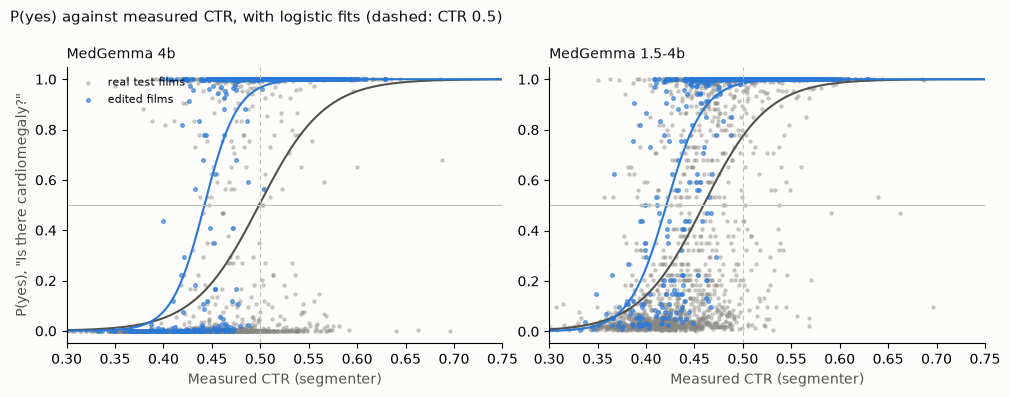

In [5]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), facecolor=SURFACE, squeeze=False)
grid = np.linspace(0.3, 0.75, 200)
for ax, m in zip(axes[0], models):
    s = scores[m][scores[m]["phrasing"] == 0]
    real, edited = s[s["group"] == "real"], s[s["group"] == "dose"]
    ax.scatter(real["ctr"], real["p_yes"], s=5, color=MUTED, alpha=0.35, label="real test films")
    ax.scatter(edited["ctr"], edited["p_yes"], s=7, color=ACCENT, alpha=0.6, label="edited films")
    for films, color in [("real", INK_2), ("edited", ACCENT)]:
        point, slope = fits[(m, films, 0)]
        ax.plot(grid, 1 / (1 + np.exp(-slope * (grid - point))), color=color, linewidth=1.5)
    ax.axvline(0.5, color=AXIS, linewidth=0.8, linestyle=(0, (4, 3)))
    ax.axhline(0.5, color=AXIS, linewidth=0.8)
    ax.set_xlim(0.3, 0.75)
    ax.set_xlabel("Measured CTR (segmenter)", color=INK_2)
    ax.set_title(f"MedGemma {m}", loc="left", color=INK, fontsize=10)
    ax.set_facecolor(SURFACE)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylabel('P(yes), "Is there cardiomegaly?"', color=INK_2)
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("P(yes) against measured CTR, with logistic fits (dashed: CTR 0.5)", x=0.01, ha="left", color=INK, fontsize=11)
fig.tight_layout()
fig.savefig(R / "dose_psychometric.png", dpi=200, facecolor=SURFACE)
plt.show()

## 4. Effusion evidence-loss control

The lung-base mask blurred at two strengths, no RadEdit, on the first 100 effusion source films
of the audit; the originals and RadEdit shams of the same films for comparison. Change in log-odds
against the original, with a 95% CI over films (one film per patient).

In [6]:
rows = []
for m in models:
    s = scores[m][scores[m]["finding"] == "effusion"]
    thr = thresholds[m].set_index(["finding", "phrasing"])["threshold"]
    for phrasing in [0, 1]:
        p = s[s["phrasing"] == phrasing]
        base = p[p["group"] == "original"].set_index("image")
        for name, sel in [("original", p["group"] == "original"), ("blur sigma 3", (p["group"] == "blur") & (p["level"] == 3)),
                          ("blur sigma 8", (p["group"] == "blur") & (p["level"] == 8)), ("RadEdit sham", p["group"] == "sham")]:
            g = p[sel].set_index("image")
            delta = (logit(g["p_yes"]) - logit(base.loc[g.index, "p_yes"])).to_numpy()
            rng = np.random.default_rng(0)
            boots = [delta[rng.integers(len(delta), size=len(delta))].mean() for _ in range(1000)]
            rows.append({"model": m, "phrasing": phrasing, "images": name, "n": len(g),
                         "median_p_yes": g["p_yes"].median(), "share_above_youden": (g["p_yes"] > thr[("effusion", phrasing)]).mean(),
                         "mean_change_log_odds": delta.mean(), "ci_low": np.percentile(boots, 2.5), "ci_high": np.percentile(boots, 97.5),
                         "median_lung_area_in_mask": g["lung_area_in_mask"].median()})
blur = pd.DataFrame(rows).round(3)
blur.to_csv(R / "dose_effusion_blur.csv", index=False)
blur

,model,phrasing,images,n,median_p_yes,share_above_youden,mean_change_log_odds,ci_low,ci_high,median_lung_area_in_mask
0,4b,0,original,100,0.000,0.25,0.000,0.000,0.000,19440.0
1,4b,0,blur sigma 3,100,0.000,0.41,0.745,0.383,1.199,18735.5
2,4b,0,blur sigma 8,100,0.000,0.88,6.230,5.095,7.442,14344.0
3,4b,0,RadEdit sham,100,0.000,0.33,0.310,-0.245,0.826,19473.0
4,4b,1,original,100,0.000,0.15,0.000,0.000,0.000,19440.0
5,4b,1,blur sigma 3,100,0.000,0.26,0.873,0.380,1.393,18735.5
6,4b,1,blur sigma 8,100,0.009,0.82,7.732,6.450,9.082,14344.0
7,4b,1,RadEdit sham,100,0.000,0.25,0.877,0.338,1.500,19473.0
8,1.5-4b,0,original,100,0.020,0.12,0.000,0.000,0.000,19440.0
9,1.5-4b,0,blur sigma 3,100,0.037,0.26,1.183,0.856,1.556,18735.5


## 5. Blank-image "yes" rates of both models (audit controls)

In [7]:
controls = pd.read_csv(R / "audit_controls.csv")
controls.pivot_table(index=["finding", "phrasing"], columns="model", values=["blank", "shuffled"])

blank        shuffled       
model                 1.5-4b     4b   1.5-4b     4b
finding      phrasing                              
cardiomegaly 0           0.0  0.000    0.000  0.000
             1           0.0  0.674    0.000  0.000
effusion     0           0.0  1.000    0.027  1.000
             1           0.0  1.000    0.000  0.058

## Takeaways

In [8]:
for _, r in switch[switch["phrasing"] == 0].iterrows():
    print(f"MedGemma {r['model']}, {r['films']} films: switch to 'yes' at CTR {r['switch_ctr']:.3f} "
          f"(95% CI {r['ci_low']:.3f}-{r['ci_high']:.3f}); overlaps 0.47-0.53: {r['ci_overlaps_0.47_0.53']}.")
step2 = switch[(switch["films"] == "edited") & ~switch["ci_overlaps_0.47_0.53"]]
print("Step 2 applies for:", sorted(set(step2["model"])) or "no model")
for _, r in blur[blur["images"] != "original"].iterrows():
    print(f"MedGemma {r['model']}, phrasing {r['phrasing']}, {r['images']}: log-odds change {r['mean_change_log_odds']:+.2f} "
          f"(95% CI {r['ci_low']:+.2f} to {r['ci_high']:+.2f}).")
print("Largest re-score difference in P(yes):", determinism["max_abs_diff_p_yes"].max())

MedGemma 4b, edited films: switch to 'yes' at CTR 0.442 (95% CI 0.435-0.449); overlaps 0.47-0.53: False.
MedGemma 4b, real films: switch to 'yes' at CTR 0.499 (95% CI 0.488-0.513); overlaps 0.47-0.53: True.
MedGemma 1.5-4b, edited films: switch to 'yes' at CTR 0.421 (95% CI 0.413-0.429); overlaps 0.47-0.53: False.
MedGemma 1.5-4b, real films: switch to 'yes' at CTR 0.459 (95% CI 0.454-0.465); overlaps 0.47-0.53: False.
Step 2 applies for: ['1.5-4b', '4b']
MedGemma 4b, phrasing 0, blur sigma 3: log-odds change +0.74 (95% CI +0.38 to +1.20).
MedGemma 4b, phrasing 0, blur sigma 8: log-odds change +6.23 (95% CI +5.09 to +7.44).
MedGemma 4b, phrasing 0, RadEdit sham: log-odds change +0.31 (95% CI -0.24 to +0.83).
MedGemma 4b, phrasing 1, blur sigma 3: log-odds change +0.87 (95% CI +0.38 to +1.39).
MedGemma 4b, phrasing 1, blur sigma 8: log-odds change +7.73 (95% CI +6.45 to +9.08).
MedGemma 4b, phrasing 1, RadEdit sham: log-odds change +0.88 (95% CI +0.34 to +1.50).
MedGemma 1.5-4b, phrasin